In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

(a) 5x5 Gaussian kernel

In [2]:
sigma = 2
size = 5

kernel = np.zeros((size, size))
center = size // 2

for i in range(size):
    for j in range(size):
        x = i - center
        y = j - center
        kernel[i, j] = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))

kernel = kernel / np.sum(kernel)

print("5x5 Gaussian Kernel (σ = 2):")
print(np.round(kernel, 4))
print(f"\nSum of kernel values: {np.sum(kernel):.4f}")

5x5 Gaussian Kernel (σ = 2):
[[0.0232 0.0338 0.0383 0.0338 0.0232]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0383 0.0558 0.0632 0.0558 0.0383]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0232 0.0338 0.0383 0.0338 0.0232]]

Sum of kernel values: 1.0000


(b) 51x51 Gaussian kernel

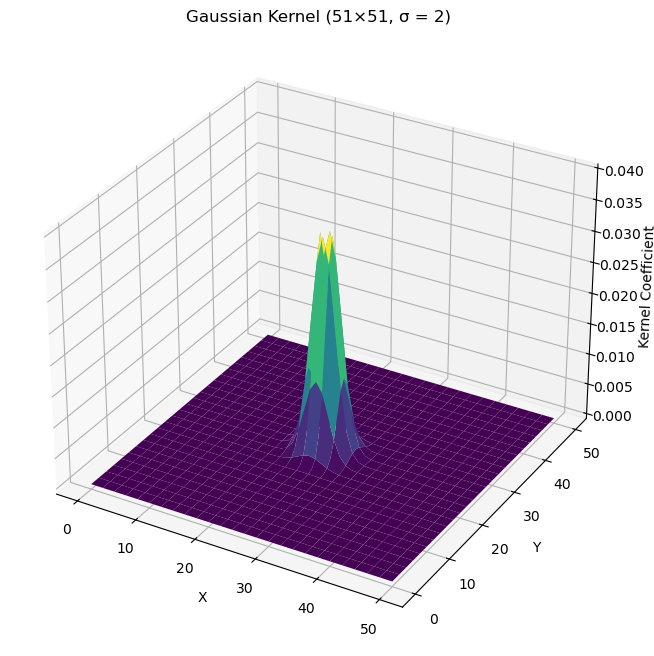

In [3]:
size_large = 51
sigma_large = 2

kernel_large = np.zeros((size_large, size_large))
center_large = size_large // 2

for i in range(size_large):
    for j in range(size_large):
        x = i - center_large
        y = j - center_large
        kernel_large[i, j] = (1 / (2 * np.pi * sigma_large**2)) * np.exp(-(x**2 + y**2) / (2 * sigma_large**2))

kernel_large = kernel_large / np.sum(kernel_large)


X = np.arange(size_large)
Y = np.arange(size_large)
X, Y = np.meshgrid(X, Y)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_large, cmap='viridis')
ax.set_title(f'Gaussian Kernel (51×51, σ = {sigma_large})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Kernel Coefficient')
plt.show()

(c) manual Gaussian smoothing

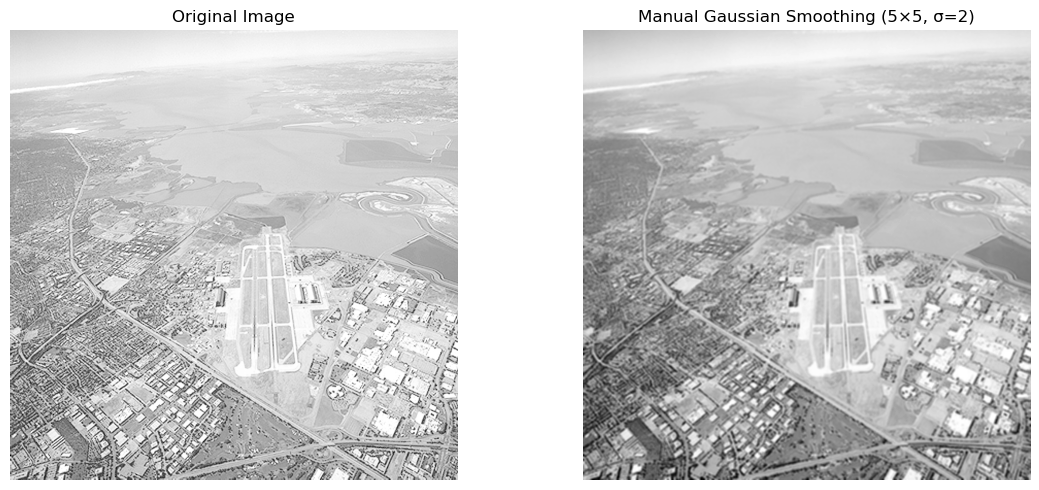

In [ ]:
img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)
img_manual_smooth = cv2.filter2D(img, -1, kernel)

# Display results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_manual_smooth, cmap='gray')
plt.title(f'Manual Gaussian Smoothing (5×5, σ={sigma})')
plt.axis('off')
plt.tight_layout()
plt.show()

(d) OpenCV's built-in Gaussian blur

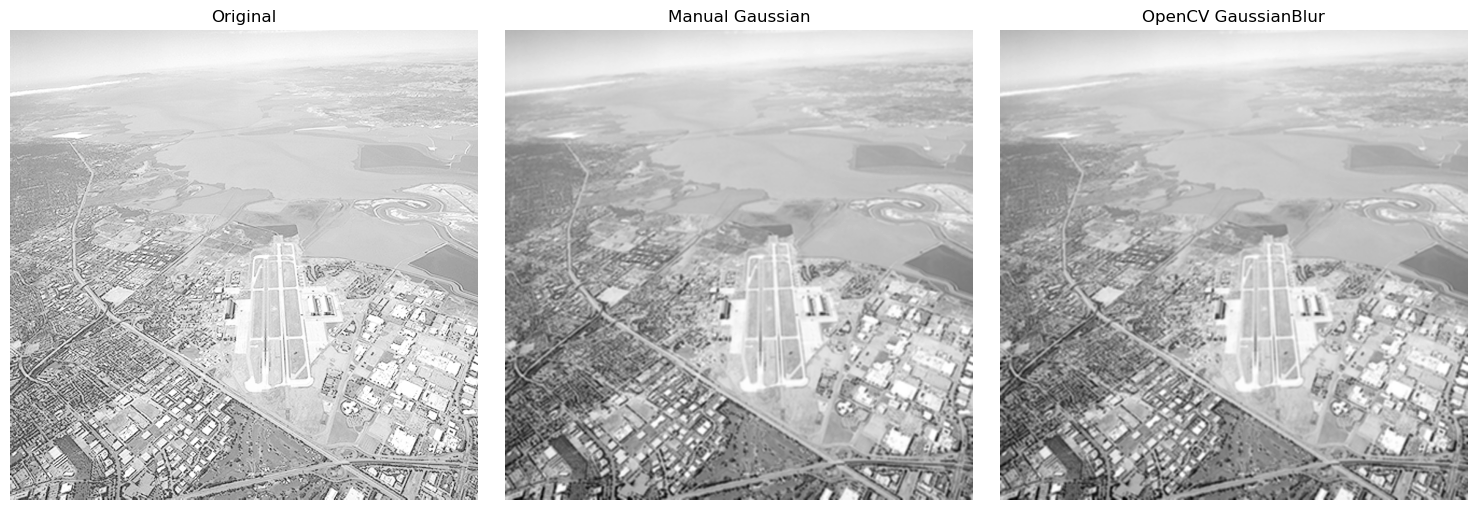

Maximum difference between manual and OpenCV: 1.00
Mean difference: 0.01


In [5]:
img_opencv_smooth = cv2.GaussianBlur(img, (5, 5), sigma)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_manual_smooth, cmap='gray')
plt.title('Manual Gaussian')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_opencv_smooth, cmap='gray')
plt.title('OpenCV GaussianBlur')
plt.axis('off')

plt.tight_layout()
plt.show()

diff = np.abs(img_manual_smooth.astype(float) - img_opencv_smooth.astype(float))
print(f"Maximum difference between manual and OpenCV: {np.max(diff):.2f}")
print(f"Mean difference: {np.mean(diff):.2f}")